In [1]:
import pandas as pd
import re

In [2]:
with open("data/schaakstudiespinsels2_from_docx.txt", encoding="latin-1") as f:
    text = f.read()

# Regex to match chess position references:

See https://chatgpt.com/share/6887334f-6c70-8007-9c71-ee98ee7ff19f

Explanation:
* `\b`: Word boundary (ensures we don’t pick up part of a longer word)

* `(?:...)`: Non-capturing group

* ~~`[KQRBNP]?`: Optional piece letter (King, Queen, Rook, Bishop, Knight, Pawn)~~

* `[KDTLP]?`: Optional piece letter (Koning, Dame, Loper, Paard)

* `[a-h][1-8]`: Required square (like b8, g6, e4)

* ~~`(?:=[QRBN])?`: Optional promotion (like f8=Q)~~

* `(?:=[DLP])?`: Optional promotion (like f8D)

* `(?:[\+\#])?`: Optional check (+) or mate (#)

* `\b`: End word boundary

In [3]:
# Match individual piece/square notations
matches = re.findall(r'\b(?:[KQRBNP]?[a-h][1-8](?:=[QRBN])?(?:[\+\#])?)\b', text)

print(len(matches))
print(len(set(matches)))

12253
216


In [4]:
# Match individual piece/square notations

import re

pattern = r"""
(?P<piece>[KDTLP]?)              # Optional Dutch piece (Koning, Dame, etc.)
(?P<square>[a-h][1-8])           # Required board square
(?P<promotion>[=]?[KDTLP])?      # Optional promotion (with or without =)
(?P<check_or_mate>[\+\#])?       # Optional check or mate
(?P<uncertainty>!|\?|!\?|!!)?    # Optional uncertainty: !, ?, !?, !!
"""

matches = list(re.finditer(pattern, text, re.VERBOSE))

print(len(matches))
print(len(set(m.group() for m in matches)))

24496
1369


In [5]:
for m in matches:
    # print(m.group(), m.groupdict())
    if m.group('uncertainty'):
        print(m.group())

Da4+?
Dd5+?
Pd2?
Pc4?
Pb1?
Db7?
De7+?
Dd5?
Ka7?
Ke5?
Ke6?
c6?
Lg8!
Pd1?
Kf3!
Kf6?
Kg5?
Pg3?
Kf1!
Pd2+?
Ke3?
Lb7!
Lc6?
Lb3!
Ka7?
d3?
Pd4?
Kh5?
Pc1+?
Kf2?
Pc1+!
Ke4?
Kb5?
Td2?
Td2?
Te2?
Kc8?
Kc6?
b7?
Pc6?
Lc8?
Pc8?
Ld5?
Ka6?
Dg7?
Kd8?
Lg1?
La7?
Lh4?
Pe7?
Le4!
Pe3?
Ke5?
Kd4?
De3+?
Dg3+?
Dg4+?
Df2+?
Df4+?
Ld6+?
Df3+?
De2+?
Kf5?
Ph6?
Pd8?
Pb6+?
Tb3+?
Kb1!
Ka2?
Pb4?
Ke6?
Pe8?
g6?
g7?
Kd5?
Kh5?
Kh5?
Kh5?
Kd7?
Db2+?
Dc3+?
Dg1+?
Dd6+?
Kg6?
Df2?
Dd2?
De2?
Kg8?
Kg8?
De4+?
Kg7?
Dg5+?
Dg4+?
Dg6+?
Kh8?
Dh5+?
De4+?
Dg1?
Pe7?
Dg1?
Kh6?
Kg8?
Ke6?
Dd4+?
Dc7+?
Ph3+?
Dh4+?
Dh6?
De5+?
e3?
e3?
Ka4?
e3?
e3!
Kb3?
Kb2?
Pd2?
Le2+?
Ld1?
Lg4?
Pd5?
Kd4?
Ke4?
g4?
Dh7+?
Kg5?
Lc8?
Kb2?
Dc4?
Kc3?
Db3+?
Kc4?
Db5+?
Kb2?
Kb1?
Lc5?
Ld6+?
Lc3?
Ta2?
Pe4?
Db2+?
Df1+?
Dd1+?
Pd4+?
De1+?
Db2+?
Pc6+?
Kb2?
Dd4?
Pa7?
Pe5?
Pc6?
Ka7?
Ke5?
Kf8?
Dd4+?
Df6+?
Dc8+?
Dd8+?
Db2+?
Kf4?
Kd3?
Dh3+?
Dh4+?
Kg7?
De4+?
Kd4?
Dc2+?
Dc7?
Dd2+?
Dc2+?
Dg6+?
De2+?
Dc5+?
Dd2+?
Lh4+?
Kh7?
Kg5?
Kg7?
Pg5?
f3?
Db2+?
Dc8+?
De8?
Dd5?
Dd6?
Da8+?
Dc5?
Dh1?
Dc5+

In [6]:
# matches = re.findall(r'(?:[KDTLP]?[a-h][1-8](?:[DTLP])?(?:[\+\#])?(?:[!|\?|!\?|!!])?)', text)

# print(len(matches))
# print(len(set(matches)))

To compare the chess board positions mentioned in your text with all possible theoretical board positions, we'll:

✅ Step-by-step plan:
* Define all legal board positions in algebraic notation (e.g., `a1`, `b2`, ..., `h8`) — total of 64.

* Extract all positions from the text using the regex we discussed (for squares like `e4`, `Kd6`, `Pf8+`, etc.).

* Normalize the extracted positions to their square coordinates (i.e., ignore the piece and annotations, keep just `a1`–`h8`).

* Compare the extracted positions against the full set and list the missing squares.

In [7]:
import re
from itertools import product

# All 64 squares on the chess board
files = 'abcdefgh'
ranks = '12345678'
all_squares = {f + r for f, r in product(files, ranks)}
all_squares

{'a1',
 'a2',
 'a3',
 'a4',
 'a5',
 'a6',
 'a7',
 'a8',
 'b1',
 'b2',
 'b3',
 'b4',
 'b5',
 'b6',
 'b7',
 'b8',
 'c1',
 'c2',
 'c3',
 'c4',
 'c5',
 'c6',
 'c7',
 'c8',
 'd1',
 'd2',
 'd3',
 'd4',
 'd5',
 'd6',
 'd7',
 'd8',
 'e1',
 'e2',
 'e3',
 'e4',
 'e5',
 'e6',
 'e7',
 'e8',
 'f1',
 'f2',
 'f3',
 'f4',
 'f5',
 'f6',
 'f7',
 'f8',
 'g1',
 'g2',
 'g3',
 'g4',
 'g5',
 'g6',
 'g7',
 'g8',
 'h1',
 'h2',
 'h3',
 'h4',
 'h5',
 'h6',
 'h7',
 'h8'}

In [8]:
mentioned_squares = set(match.group('square') for match in matches)
len(mentioned_squares)

64

In [9]:
# Compare with full board
missing_squares = sorted(all_squares - mentioned_squares)

print(f"Squares mentioned in text ({len(mentioned_squares)}): {sorted(mentioned_squares)}")
print(f"\nSquares NOT mentioned in text ({len(missing_squares)}): {missing_squares}")

Squares mentioned in text (64): ['a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'd1', 'd2', 'd3', 'd4', 'd5', 'd6', 'd7', 'd8', 'e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'g1', 'g2', 'g3', 'g4', 'g5', 'g6', 'g7', 'g8', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'h7', 'h8']

Squares NOT mentioned in text (0): []


#  analyze which pieces visited which squares

In [10]:
# Count each unique piece-square reference
from collections import Counter
raw_positions = Counter(match.group() for match in matches)
raw_positions.most_common()

[('Kd6', 182),
 ('Kc6', 171),
 ('b7', 171),
 ('Ke5', 162),
 ('Ke7', 160),
 ('Ke6', 156),
 ('Kd5', 156),
 ('Kf6', 152),
 ('Kd3', 149),
 ('Kb4', 146),
 ('Ke3', 146),
 ('Kd4', 143),
 ('Kc7', 143),
 ('Ke4', 143),
 ('Kc5', 137),
 ('Kf5', 133),
 ('Kf3', 132),
 ('Kb5', 129),
 ('Kd7', 128),
 ('Kb7', 127),
 ('Kg2', 127),
 ('Kg1', 127),
 ('Ka6', 126),
 ('a5', 125),
 ('Kc4', 121),
 ('Kb2', 120),
 ('Kg6', 119),
 ('Kb3', 118),
 ('Kg3', 118),
 ('Kb1', 116),
 ('Kc3', 116),
 ('Kb8', 115),
 ('Kf1', 115),
 ('f2', 114),
 ('a3', 108),
 ('Kf7', 107),
 ('d6', 107),
 ('a7', 106),
 ('c7', 104),
 ('Kf4', 104),
 ('Ka2', 103),
 ('e4', 103),
 ('c6', 103),
 ('d5', 102),
 ('Kg7', 102),
 ('Kf2', 102),
 ('e2', 101),
 ('a6', 100),
 ('Kg4', 99),
 ('Ka7', 99),
 ('Kc2', 95),
 ('a8', 95),
 ('Kg5', 95),
 ('Ke2', 95),
 ('b5', 94),
 ('e5', 94),
 ('b3', 93),
 ('f4', 93),
 ('h3', 93),
 ('e6', 93),
 ('Kg8', 92),
 ('a4', 91),
 ('g2', 91),
 ('b4', 91),
 ('Kh1', 90),
 ('Kd2', 88),
 ('h4', 88),
 ('Ka1', 87),
 ('b2', 87),
 ('a1', 87

In [11]:

data = []
for match in matches:
    dct = match.groupdict()
    dct['file'] = dct['square'][0]
    dct['rank'] = dct['square'][1]
    dct['position'] = match.group()
    dct['count'] = raw_positions[match.group()]
    data.append(dct)

df = pd.DataFrame(data)
# df[['file', 'rank']] = df['square'].str.extract(r'([a-h])([1-8])')
df

,piece,square,promotion,check_or_mate,uncertainty,file,rank,position,count
0,,d1,None,None,None,d,1,d1,68
1,,b3,None,None,None,b,3,b3,93
2,P,a5,None,+,None,a,5,Pa5+,20
3,K,a2,None,None,None,a,2,Ka2,103
4,P,c4,None,None,None,c,4,Pc4,63
...,...,...,...,...,...,...,...,...,...
24491,L,e5,None,+,None,e,5,Le5+,25
24492,K,e4,None,None,None,e,4,Ke4,143
24493,,a1,None,None,None,a,1,a1,87
24494,,f5,None,None,None,f,5,f5,83


In [12]:
# Create pivot table: rows = rank, cols = file, values = count
heatmap_data = df.pivot_table(index='rank', columns='file', values='count', aggfunc='sum', fill_value=0)
heatmap_data = heatmap_data.sort_index(ascending=False)  # rank 8 at top
heatmap_data

file,a,b,c,d,e,f,g,h
rank,,,,,,,,
8,15905,24227,15096,14137,14748,7344,14014,11620
7,22800,49344,35723,24575,37248,19609,15702,10479
6,27370,23426,48523,53471,40879,35016,20922,9539
5,26170,28573,30114,47125,47944,33424,15564,12491
4,13992,33263,29174,39892,41969,26751,17924,13836
3,16618,26876,27889,31982,35301,27183,23146,14038
2,19033,24922,17764,19215,23048,27538,26716,12744
1,19483,21665,10725,12203,16691,20000,19961,12732


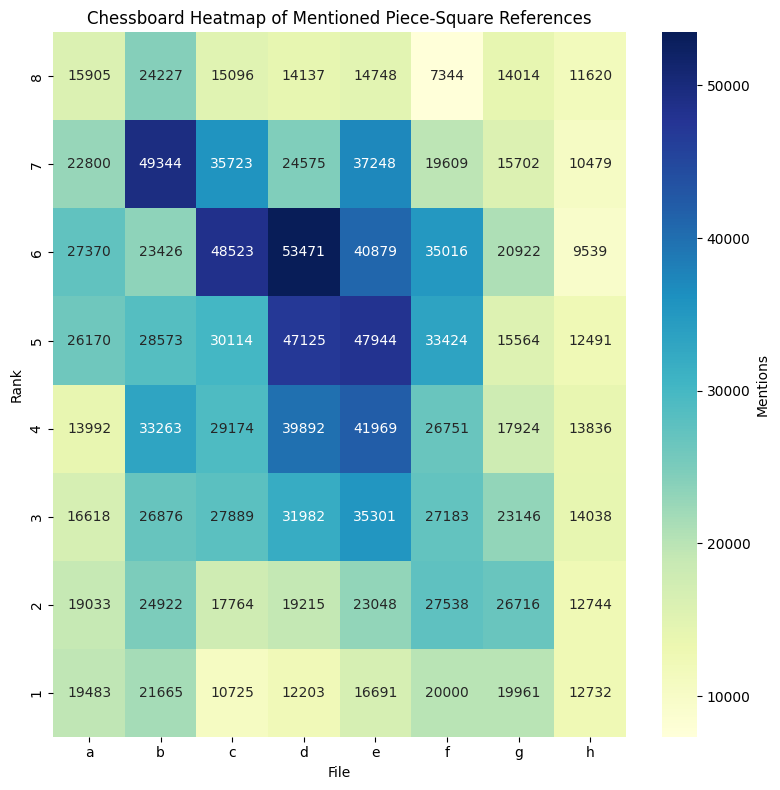

In [13]:
# Plot heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Mentions'})
plt.title("Chessboard Heatmap of Mentioned Piece-Square References")
plt.xlabel("File")
plt.ylabel("Rank")
plt.tight_layout()
plt.show()

Here's the heatmap showing how frequently specific piece-square references (like `Ke7`, `Pd6`, etc.) appear in the text:

* The board is oriented with rank 8 at the top, like in standard chess diagrams.

* The darker the color, the more frequently that square was referenced.

## Separate heatmaps per piece (e.g., only Kings, Knights)

In [14]:
# Create a dictionary of heatmaps per piece
piece_types = sorted(df['piece'].unique())
heatmaps = {}
piece_types

['', 'D', 'K', 'L', 'P', 'T']

In [15]:
# Compute full set of squares per piece type (all 64 for each)
piece_square_universe = {piece: {f + r for f in files for r in ranks} for piece in piece_types}
piece_square_universe

{'': {'a1',
  'a2',
  'a3',
  'a4',
  'a5',
  'a6',
  'a7',
  'a8',
  'b1',
  'b2',
  'b3',
  'b4',
  'b5',
  'b6',
  'b7',
  'b8',
  'c1',
  'c2',
  'c3',
  'c4',
  'c5',
  'c6',
  'c7',
  'c8',
  'd1',
  'd2',
  'd3',
  'd4',
  'd5',
  'd6',
  'd7',
  'd8',
  'e1',
  'e2',
  'e3',
  'e4',
  'e5',
  'e6',
  'e7',
  'e8',
  'f1',
  'f2',
  'f3',
  'f4',
  'f5',
  'f6',
  'f7',
  'f8',
  'g1',
  'g2',
  'g3',
  'g4',
  'g5',
  'g6',
  'g7',
  'g8',
  'h1',
  'h2',
  'h3',
  'h4',
  'h5',
  'h6',
  'h7',
  'h8'},
 'D': {'a1',
  'a2',
  'a3',
  'a4',
  'a5',
  'a6',
  'a7',
  'a8',
  'b1',
  'b2',
  'b3',
  'b4',
  'b5',
  'b6',
  'b7',
  'b8',
  'c1',
  'c2',
  'c3',
  'c4',
  'c5',
  'c6',
  'c7',
  'c8',
  'd1',
  'd2',
  'd3',
  'd4',
  'd5',
  'd6',
  'd7',
  'd8',
  'e1',
  'e2',
  'e3',
  'e4',
  'e5',
  'e6',
  'e7',
  'e8',
  'f1',
  'f2',
  'f3',
  'f4',
  'f5',
  'f6',
  'f7',
  'f8',
  'g1',
  'g2',
  'g3',
  'g4',
  'g5',
  'g6',
  'g7',
  'g8',
  'h1',
  'h2',
  'h3',
  'h4'

# Advanced Chess Position Analysis

This section provides deeper insights into the chess positions mentioned in the text, exploring patterns that reveal the strategic themes and tactical motifs discussed in the endgame studies.


In [16]:
# Import additional libraries for advanced analysis
import numpy as np
from collections import defaultdict
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10


## 1. Piece Mobility Analysis

Let's analyze which pieces move to which squares most frequently. This reveals the strategic importance of different board areas for different piece types.


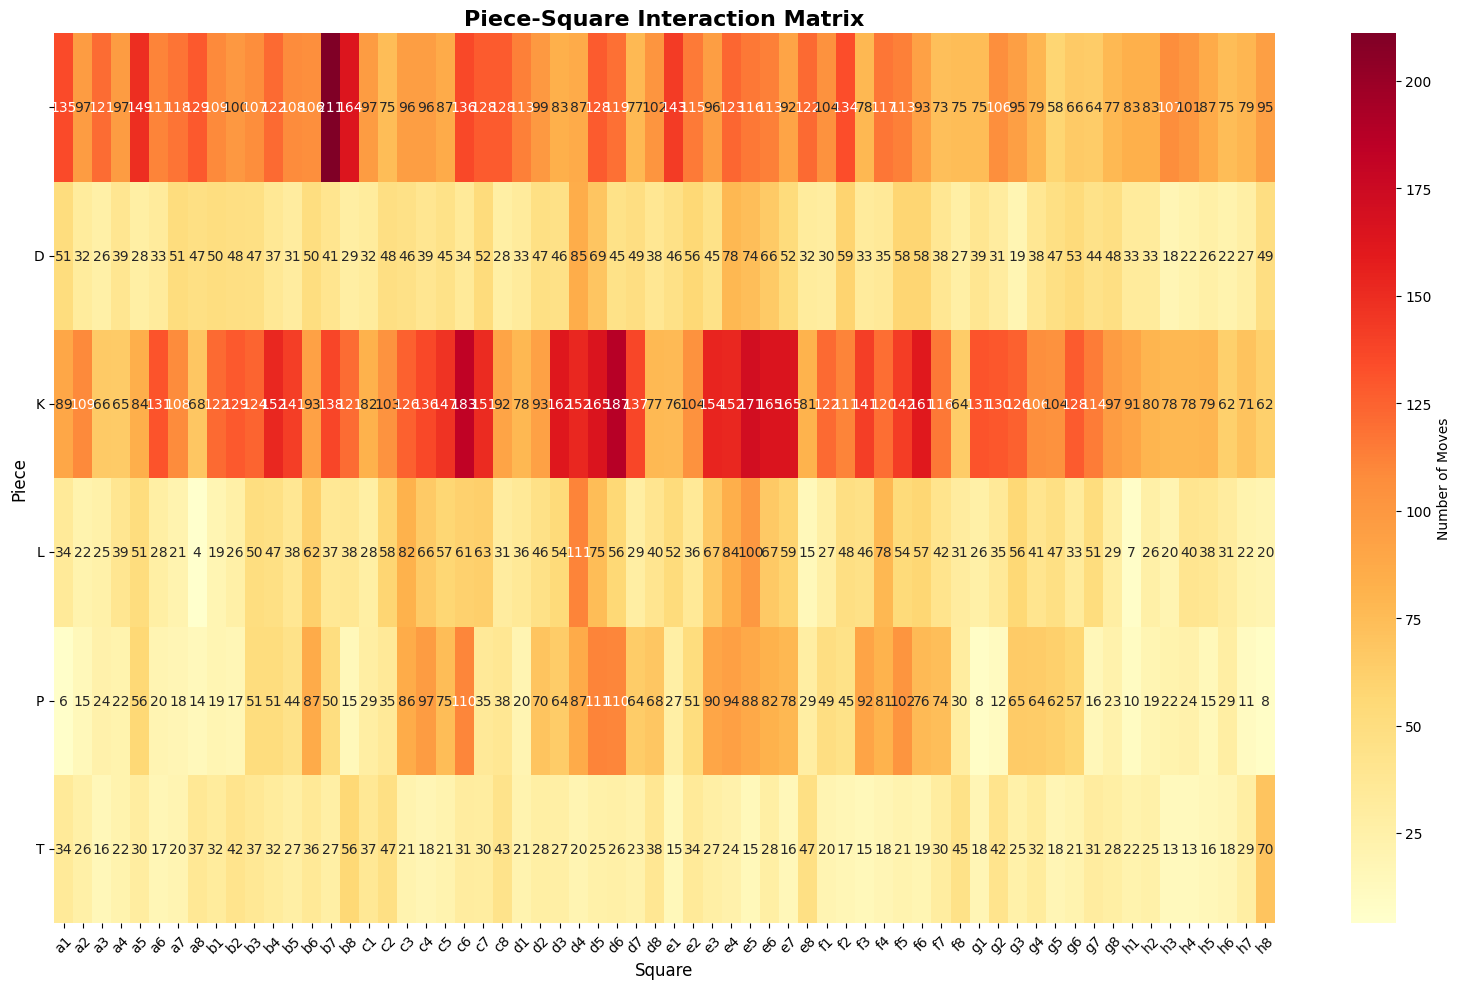

Top 15 Piece-Square Combinations:
piece square  count
          b7    211
    K     d6    187
    K     c6    183
    K     e5    171
    K     d5    165
    K     e6    165
    K     e7    165
          b8    164
    K     d3    162
    K     f6    161
    K     e3    154
    K     b4    152
    K     d4    152
    K     e4    152
    K     c7    151


In [17]:
# Create piece-square interaction matrix
piece_square_matrix = df.groupby(['piece', 'square']).size().unstack(fill_value=0)

# Create heatmap for piece-square interactions
plt.figure(figsize=(16, 10))
sns.heatmap(piece_square_matrix, cmap='YlOrRd', annot=True, fmt='d', 
            cbar_kws={'label': 'Number of Moves'})
plt.title('Piece-Square Interaction Matrix', fontsize=16, fontweight='bold')
plt.xlabel('Square', fontsize=12)
plt.ylabel('Piece', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Find most active piece-square combinations
piece_square_counts = df.groupby(['piece', 'square']).size().reset_index(name='count')
top_combinations = piece_square_counts.nlargest(15, 'count')

print("Top 15 Piece-Square Combinations:")
print(top_combinations.to_string(index=False))


## 2. Board Region Analysis

Chess strategy often revolves around controlling different regions of the board. Let's analyze activity patterns across board regions.


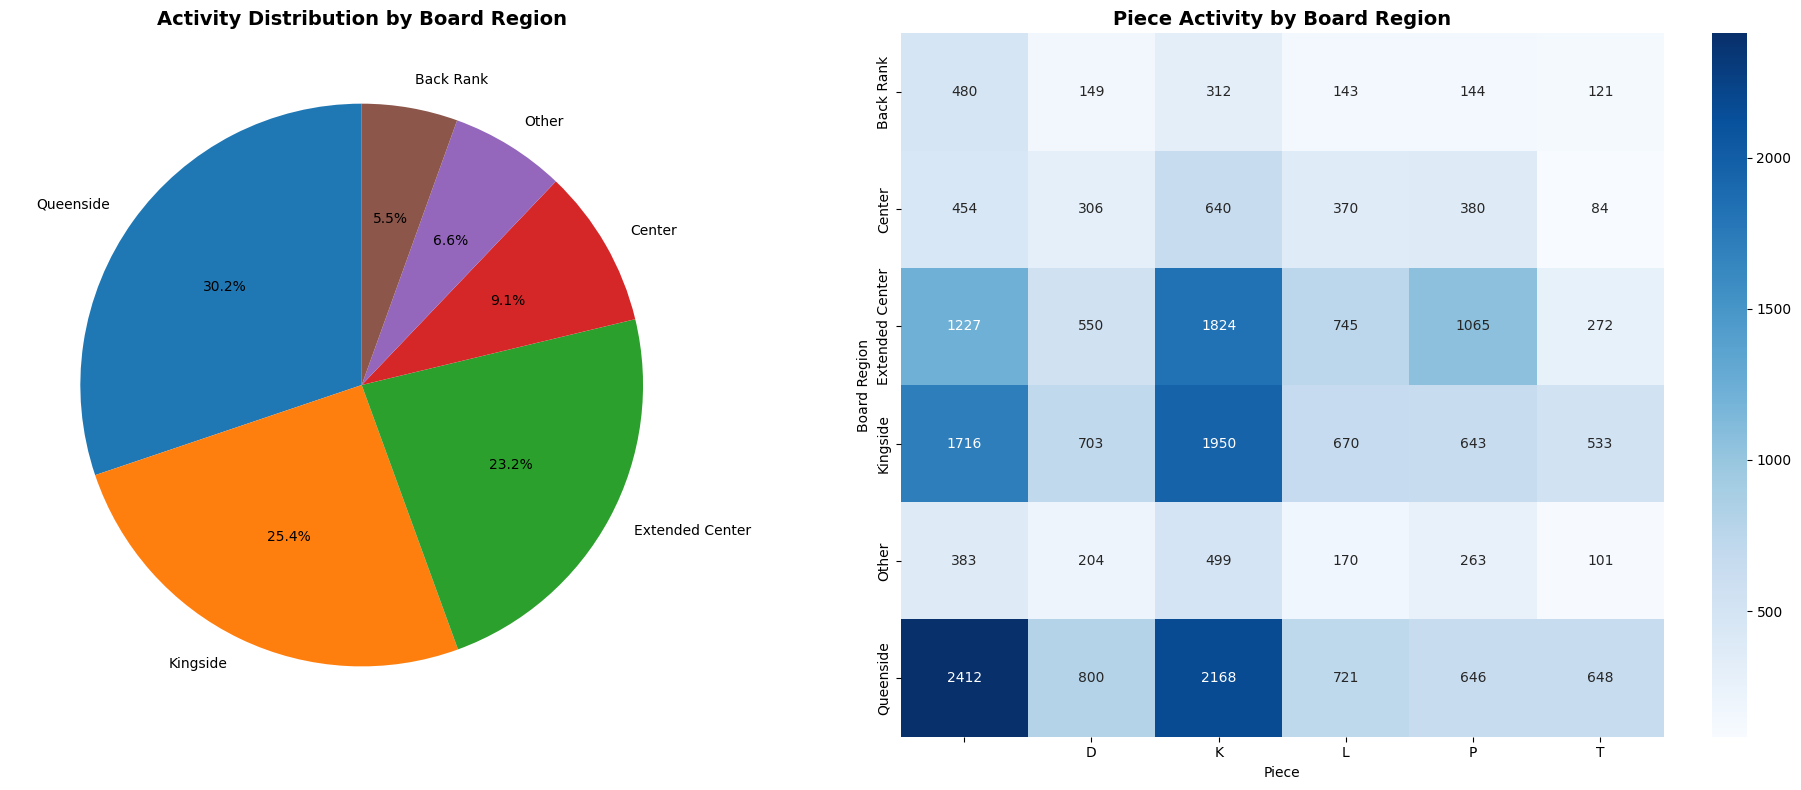

Region Activity Summary:
Queenside: 7395 moves (30.2%)
Kingside: 6215 moves (25.4%)
Extended Center: 5683 moves (23.2%)
Center: 2234 moves (9.1%)
Other: 1620 moves (6.6%)
Back Rank: 1349 moves (5.5%)


In [18]:
# Define board regions
def get_board_region(square):
    file, rank = square[0], int(square[1])
    
    # Center squares (d4, d5, e4, e5)
    if square in ['d4', 'd5', 'e4', 'e5']:
        return 'Center'
    
    # Extended center (c3-c6, d3-d6, e3-e6, f3-f6)
    elif file in 'cdef' and rank in [3, 4, 5, 6]:
        return 'Extended Center'
    
    # Kingside (files f, g, h)
    elif file in 'fgh':
        return 'Kingside'
    
    # Queenside (files a, b, c)
    elif file in 'abc':
        return 'Queenside'
    
    # Back ranks (ranks 1, 8)
    elif rank in [1, 8]:
        return 'Back Rank'
    
    # Edge squares
    elif file in 'ah' or rank in [1, 8]:
        return 'Edge'
    
    else:
        return 'Other'

df['region'] = df['square'].apply(get_board_region)

# Analyze region activity
region_counts = df['region'].value_counts()
region_piece_counts = df.groupby(['region', 'piece']).size().unstack(fill_value=0)

# Visualize region activity
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Region activity pie chart
ax1.pie(region_counts.values, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Activity Distribution by Board Region', fontsize=14, fontweight='bold')

# Region-piece interaction heatmap
sns.heatmap(region_piece_counts, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Piece Activity by Board Region', fontsize=14, fontweight='bold')
ax2.set_xlabel('Piece')
ax2.set_ylabel('Board Region')

plt.tight_layout()
plt.show()

print("Region Activity Summary:")
for region, count in region_counts.items():
    percentage = (count / len(df)) * 100
    print(f"{region}: {count} moves ({percentage:.1f}%)")


## 3. File and Rank Analysis

Analyzing activity patterns across files (columns) and ranks (rows) reveals strategic preferences and tactical themes.


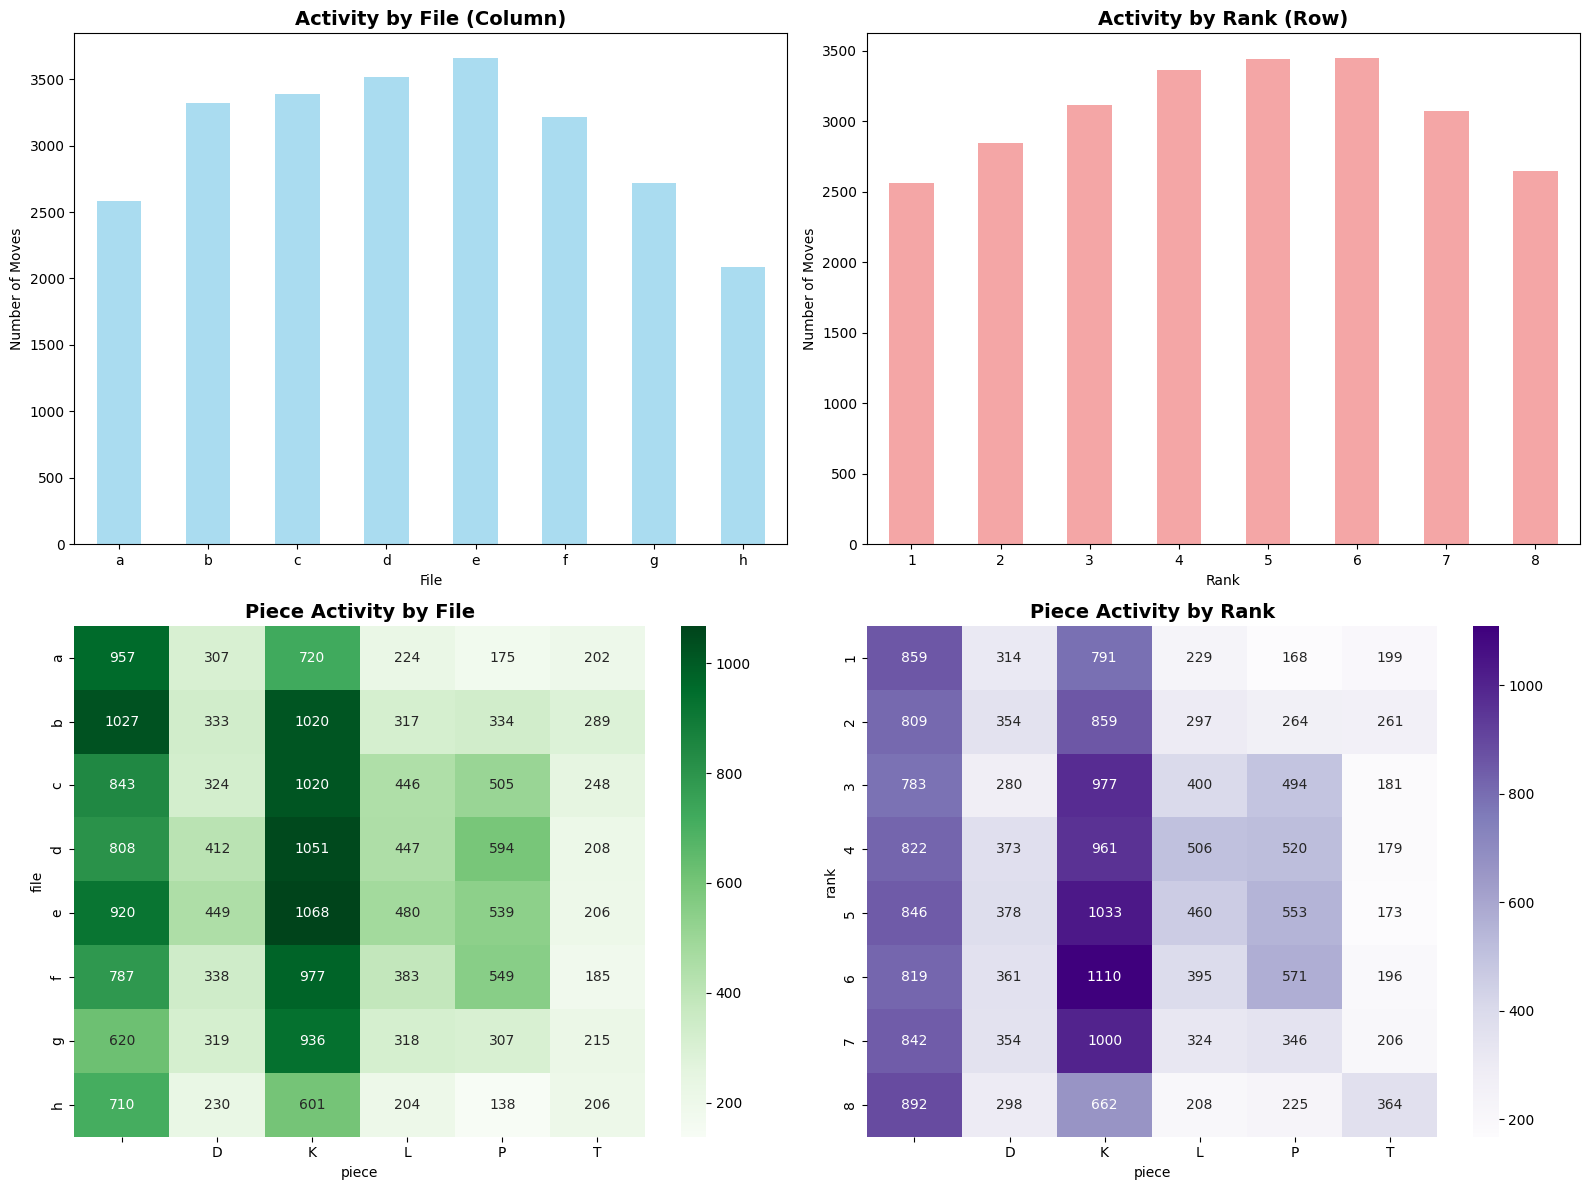

File Activity Statistics:
Most active file: e (3662 moves)
Least active file: h (2089 moves)
File activity range: 1573

Rank Activity Statistics:
Most active rank: 6 (3452 moves)
Least active rank: 1 (2560 moves)
Rank activity range: 892


In [19]:
# Analyze file and rank activity
file_counts = df['file'].value_counts().sort_index()
rank_counts = df['rank'].value_counts().sort_index()

# Create subplots for file and rank analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# File activity bar chart
file_counts.plot(kind='bar', ax=ax1, color='skyblue', alpha=0.7)
ax1.set_title('Activity by File (Column)', fontsize=14, fontweight='bold')
ax1.set_xlabel('File')
ax1.set_ylabel('Number of Moves')
ax1.tick_params(axis='x', rotation=0)

# Rank activity bar chart
rank_counts.plot(kind='bar', ax=ax2, color='lightcoral', alpha=0.7)
ax2.set_title('Activity by Rank (Row)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Number of Moves')
ax2.tick_params(axis='x', rotation=0)

# File-piece interaction
file_piece_counts = df.groupby(['file', 'piece']).size().unstack(fill_value=0)
sns.heatmap(file_piece_counts, annot=True, fmt='d', cmap='Greens', ax=ax3)
ax3.set_title('Piece Activity by File', fontsize=14, fontweight='bold')

# Rank-piece interaction
rank_piece_counts = df.groupby(['rank', 'piece']).size().unstack(fill_value=0)
sns.heatmap(rank_piece_counts, annot=True, fmt='d', cmap='Purples', ax=ax4)
ax4.set_title('Piece Activity by Rank', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Statistical analysis
print("File Activity Statistics:")
print(f"Most active file: {file_counts.idxmax()} ({file_counts.max()} moves)")
print(f"Least active file: {file_counts.idxmin()} ({file_counts.min()} moves)")
print(f"File activity range: {file_counts.max() - file_counts.min()}")

print("\nRank Activity Statistics:")
print(f"Most active rank: {rank_counts.idxmax()} ({rank_counts.max()} moves)")
print(f"Least active rank: {rank_counts.idxmin()} ({rank_counts.min()} moves)")
print(f"Rank activity range: {rank_counts.max() - rank_counts.min()}")


## 4. Center Control Analysis

The center of the board (d4, d5, e4, e5) is crucial in chess strategy. Let's analyze how these key squares are used.


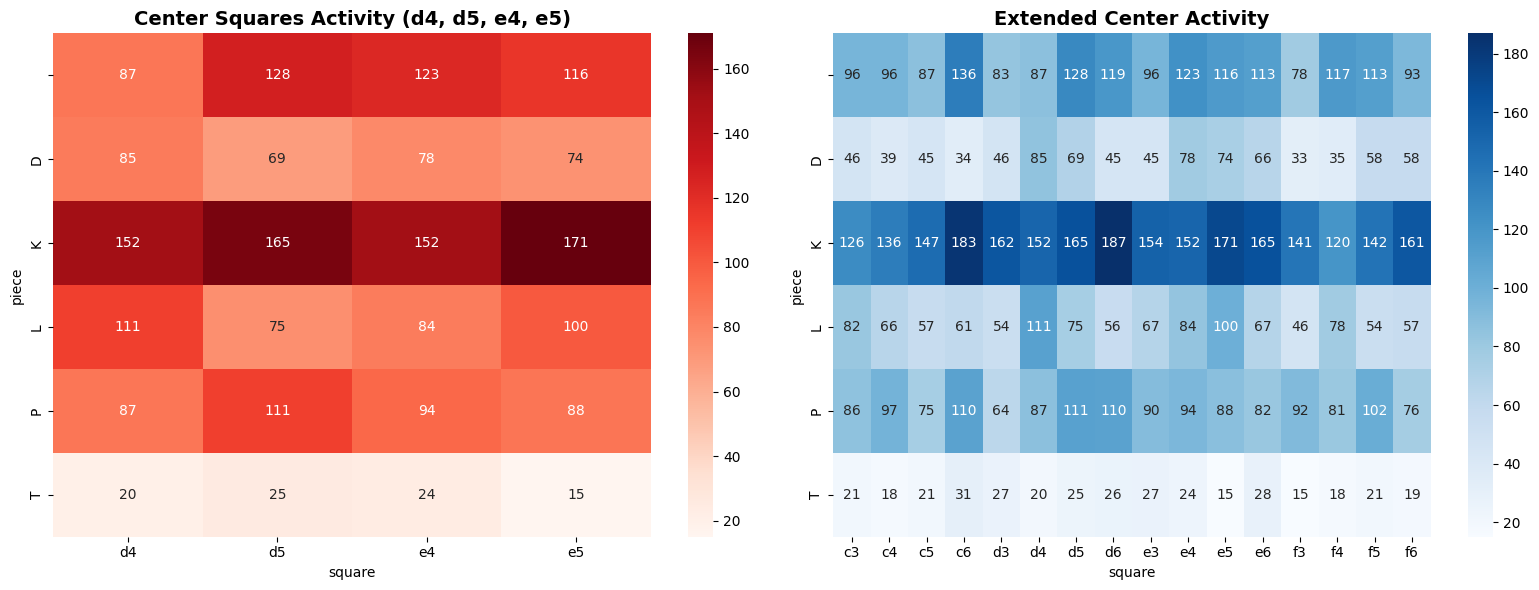

Center Control Statistics:
Center square moves: 2234 (9.1% of all moves)
Extended center moves: 7917 (32.3% of all moves)

Most active center squares:
d5: 573 moves
e5: 564 moves
e4: 555 moves
d4: 542 moves

Piece activity in center:
K: 640 moves
: 454 moves
P: 380 moves
L: 370 moves
D: 306 moves
T: 84 moves


In [20]:
# Analyze center control
center_squares = ['d4', 'd5', 'e4', 'e5']
extended_center = ['c3', 'c4', 'c5', 'c6', 'd3', 'd4', 'd5', 'd6', 
                   'e3', 'e4', 'e5', 'e6', 'f3', 'f4', 'f5', 'f6']

df['is_center'] = df['square'].isin(center_squares)
df['is_extended_center'] = df['square'].isin(extended_center)

# Center activity analysis
center_activity = df[df['is_center']].groupby(['square', 'piece']).size().reset_index(name='count')
extended_center_activity = df[df['is_extended_center']].groupby(['square', 'piece']).size().reset_index(name='count')

# Create center control visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Center squares activity
center_pivot = center_activity.pivot(index='piece', columns='square', values='count').fillna(0)
sns.heatmap(center_pivot, annot=True, fmt='.0f', cmap='Reds', ax=ax1)
ax1.set_title('Center Squares Activity (d4, d5, e4, e5)', fontsize=14, fontweight='bold')

# Extended center activity
extended_pivot = extended_center_activity.pivot(index='piece', columns='square', values='count').fillna(0)
sns.heatmap(extended_pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax2)
ax2.set_title('Extended Center Activity', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Center control statistics
center_moves = len(df[df['is_center']])
extended_center_moves = len(df[df['is_extended_center']])
total_moves = len(df)

print("Center Control Statistics:")
print(f"Center square moves: {center_moves} ({center_moves/total_moves*100:.1f}% of all moves)")
print(f"Extended center moves: {extended_center_moves} ({extended_center_moves/total_moves*100:.1f}% of all moves)")

print("\nMost active center squares:")
center_square_counts = df[df['is_center']]['square'].value_counts()
for square, count in center_square_counts.items():
    print(f"{square}: {count} moves")

print("\nPiece activity in center:")
center_piece_counts = df[df['is_center']]['piece'].value_counts()
for piece, count in center_piece_counts.items():
    print(f"{piece}: {count} moves")


## 5. Endgame-Specific Pattern Analysis

Since this text focuses on chess endgames, let's analyze patterns specific to endgame play.


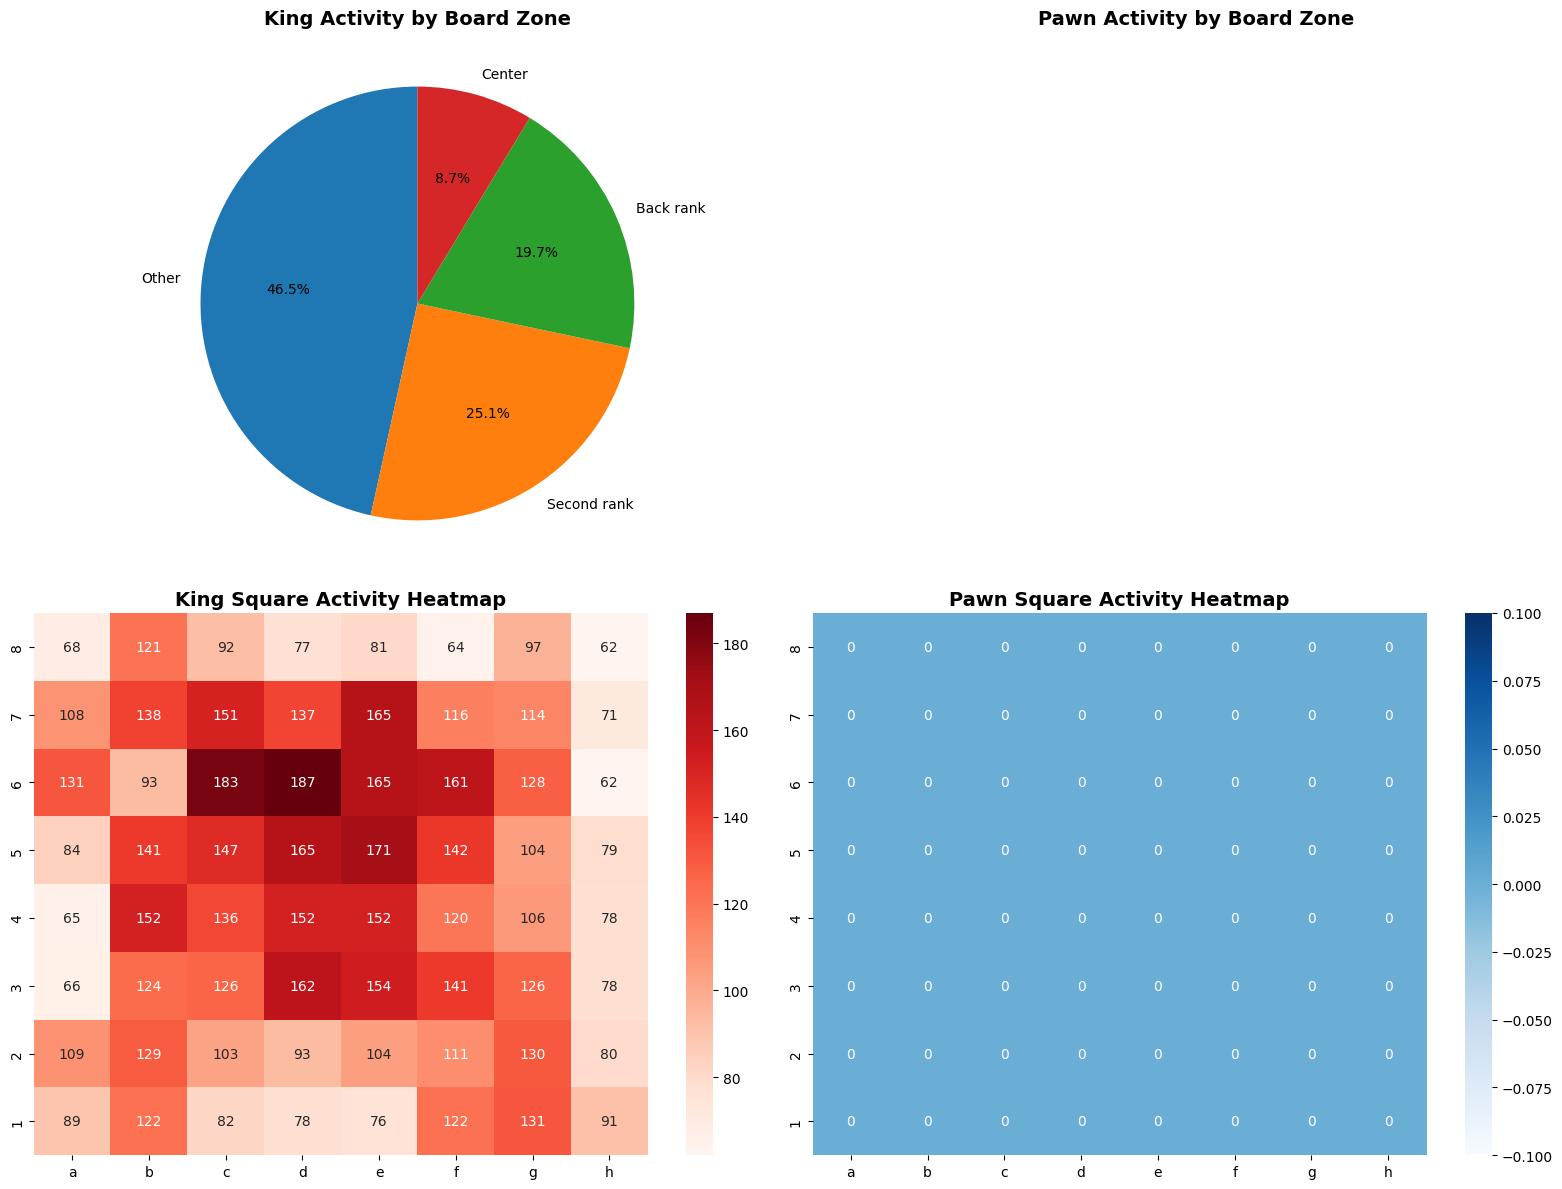

Endgame Pattern Statistics:
Total king moves: 7393
Total pawn moves: 0
King moves as % of total: 30.2%
Pawn moves as % of total: 0.0%

Most active king squares:
d6: 187 moves
c6: 183 moves
e5: 171 moves
e6: 165 moves
d5: 165 moves
e7: 165 moves
d3: 162 moves
f6: 161 moves
e3: 154 moves
d4: 152 moves

Most active pawn squares:


In [21]:
# Endgame-specific analysis
# King activity (crucial in endgames)
king_moves = df[df['piece'] == 'K'].copy()
king_moves['king_zone'] = king_moves['square'].apply(lambda s: 
    'Back rank' if s[1] in '18' else 
    'Second rank' if s[1] in '27' else 
    'Center' if s in ['d4', 'd5', 'e4', 'e5'] else 'Other')

# Pawn activity (promotion squares, key ranks)
pawn_moves = df[df['piece'] == 'pawn'].copy()
pawn_moves['promotion_zone'] = pawn_moves['square'].apply(lambda s:
    'Promotion square' if s[1] in '18' else
    'Seventh rank' if s[1] in '27' else 'Other')

# Create endgame analysis visualizations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# King activity by zone
king_zone_counts = king_moves['king_zone'].value_counts()
ax1.pie(king_zone_counts.values, labels=king_zone_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('King Activity by Board Zone', fontsize=14, fontweight='bold')

# Pawn activity by zone
pawn_zone_counts = pawn_moves['promotion_zone'].value_counts()
ax2.pie(pawn_zone_counts.values, labels=pawn_zone_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('Pawn Activity by Board Zone', fontsize=14, fontweight='bold')

# King square activity heatmap
king_square_counts = king_moves['square'].value_counts()
king_heatmap_data = pd.DataFrame(index=list('87654321'), columns=list('abcdefgh'))
king_heatmap_data = king_heatmap_data.fillna(0)

for square, count in king_square_counts.items():
    file, rank = square[0], square[1]
    king_heatmap_data.loc[rank, file] = count

sns.heatmap(king_heatmap_data, cmap='Reds', annot=True, fmt='.0f', ax=ax3)
ax3.set_title('King Square Activity Heatmap', fontsize=14, fontweight='bold')

# Pawn square activity heatmap
pawn_square_counts = pawn_moves['square'].value_counts()
pawn_heatmap_data = pd.DataFrame(index=list('87654321'), columns=list('abcdefgh'))
pawn_heatmap_data = pawn_heatmap_data.fillna(0)

for square, count in pawn_square_counts.items():
    file, rank = square[0], square[1]
    pawn_heatmap_data.loc[rank, file] = count

sns.heatmap(pawn_heatmap_data, cmap='Blues', annot=True, fmt='.0f', ax=ax4)
ax4.set_title('Pawn Square Activity Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Endgame statistics
print("Endgame Pattern Statistics:")
print(f"Total king moves: {len(king_moves)}")
print(f"Total pawn moves: {len(pawn_moves)}")
print(f"King moves as % of total: {len(king_moves)/len(df)*100:.1f}%")
print(f"Pawn moves as % of total: {len(pawn_moves)/len(df)*100:.1f}%")

print("\nMost active king squares:")
for square, count in king_square_counts.head(10).items():
    print(f"{square}: {count} moves")

print("\nMost active pawn squares:")
for square, count in pawn_square_counts.head(10).items():
    print(f"{square}: {count} moves")


## 6. Tactical Pattern Analysis

Let's analyze tactical patterns like checks, checkmates, and promotions to understand the tactical themes in the endgame studies.


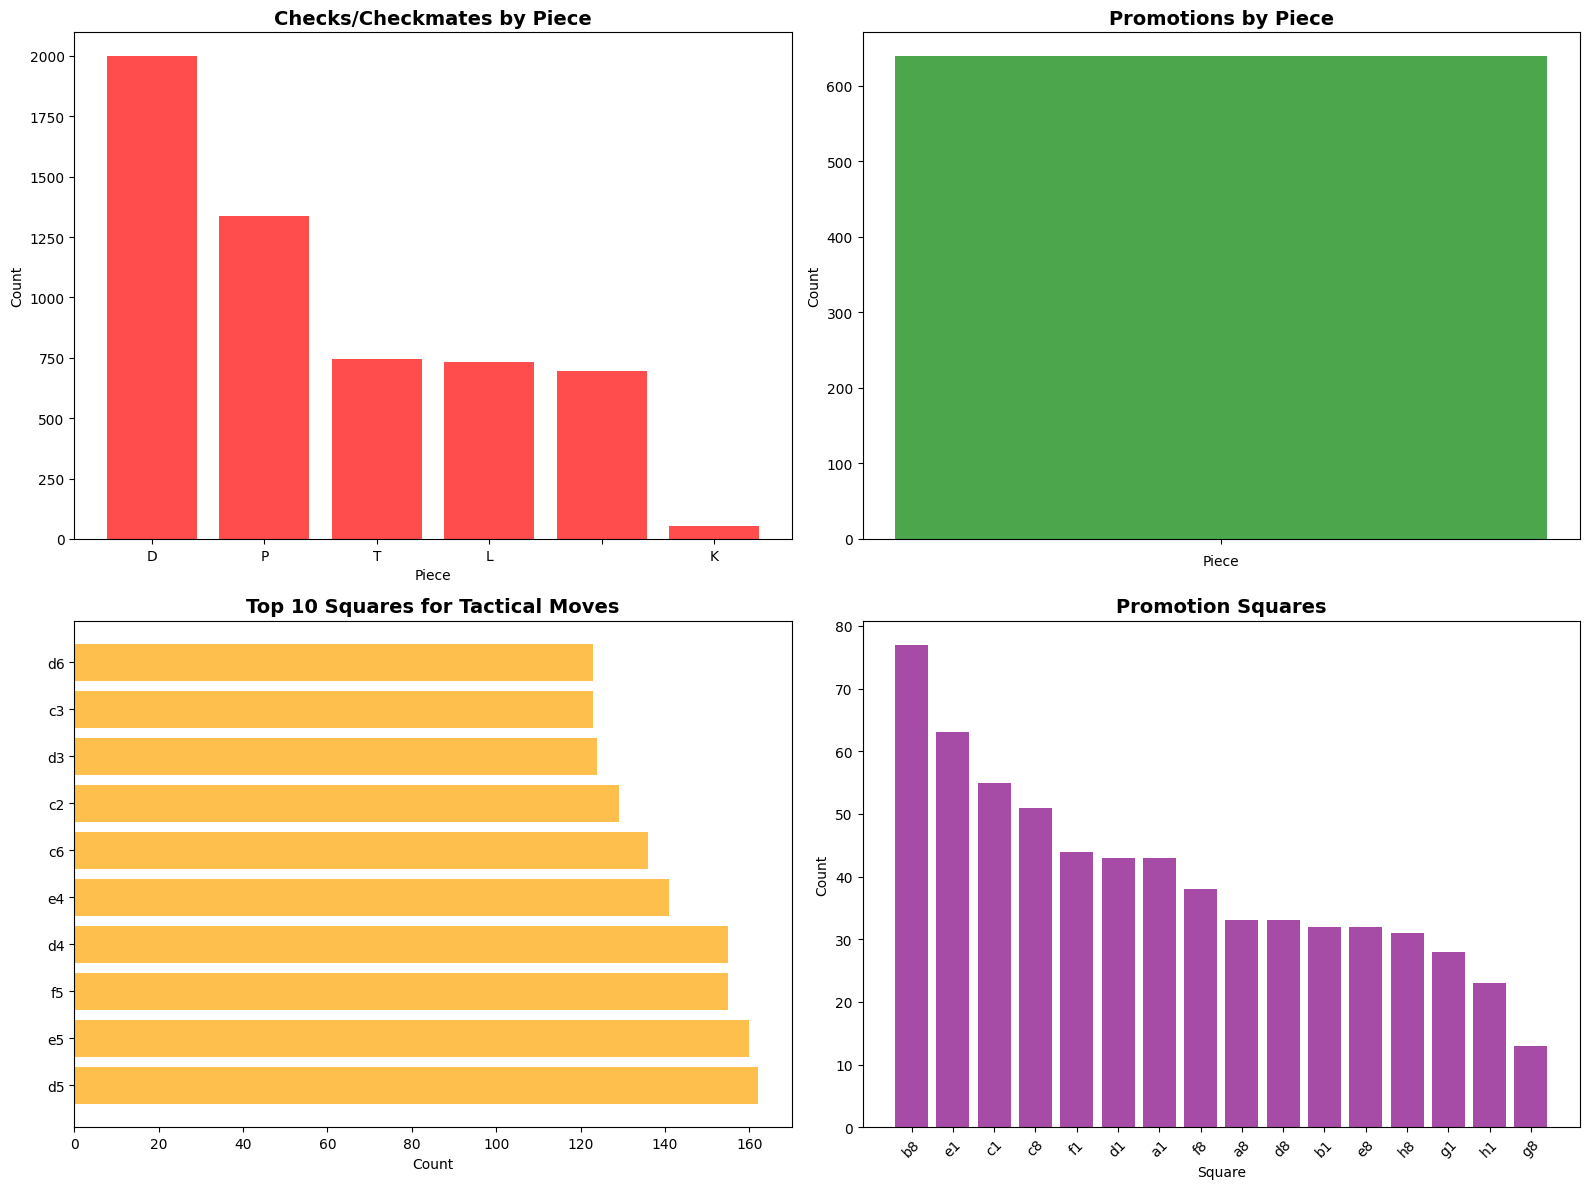

Tactical Pattern Statistics:
Total tactical moves (checks/checkmates): 5564
Total promotion moves: 639
Tactical moves as % of total: 22.7%
Promotion moves as % of total: 2.6%

Tactical moves by piece:
D: 1998 moves
P: 1337 moves
T: 745 moves
L: 732 moves
: 697 moves
K: 55 moves

Promotion moves by piece:
: 639 moves


In [22]:
# Tactical pattern analysis
tactical_moves = df[df['check_or_mate'].notna()].copy()
promotion_moves = df[df['promotion'].notna()].copy()

# Analyze tactical patterns
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Check/Checkmate by piece
if len(tactical_moves) > 0:
    tactical_piece_counts = tactical_moves['piece'].value_counts()
    ax1.bar(tactical_piece_counts.index, tactical_piece_counts.values, color='red', alpha=0.7)
    ax1.set_title('Checks/Checkmates by Piece', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Piece')
    ax1.set_ylabel('Count')
else:
    ax1.text(0.5, 0.5, 'No tactical moves found', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Checks/Checkmates by Piece', fontsize=14, fontweight='bold')

# Promotion analysis
if len(promotion_moves) > 0:
    promotion_piece_counts = promotion_moves['piece'].value_counts()
    ax2.bar(promotion_piece_counts.index, promotion_piece_counts.values, color='green', alpha=0.7)
    ax2.set_title('Promotions by Piece', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Piece')
    ax2.set_ylabel('Count')
else:
    ax2.text(0.5, 0.5, 'No promotions found', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Promotions by Piece', fontsize=14, fontweight='bold')

# Tactical moves by square
if len(tactical_moves) > 0:
    tactical_square_counts = tactical_moves['square'].value_counts().head(10)
    ax3.barh(range(len(tactical_square_counts)), tactical_square_counts.values, color='orange', alpha=0.7)
    ax3.set_yticks(range(len(tactical_square_counts)))
    ax3.set_yticklabels(tactical_square_counts.index)
    ax3.set_title('Top 10 Squares for Tactical Moves', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Count')
else:
    ax3.text(0.5, 0.5, 'No tactical moves found', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title('Top 10 Squares for Tactical Moves', fontsize=14, fontweight='bold')

# Promotion squares
if len(promotion_moves) > 0:
    promotion_square_counts = promotion_moves['square'].value_counts()
    ax4.bar(promotion_square_counts.index, promotion_square_counts.values, color='purple', alpha=0.7)
    ax4.set_title('Promotion Squares', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Square')
    ax4.set_ylabel('Count')
    ax4.tick_params(axis='x', rotation=45)
else:
    ax4.text(0.5, 0.5, 'No promotions found', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title('Promotion Squares', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Tactical statistics
print("Tactical Pattern Statistics:")
print(f"Total tactical moves (checks/checkmates): {len(tactical_moves)}")
print(f"Total promotion moves: {len(promotion_moves)}")
print(f"Tactical moves as % of total: {len(tactical_moves)/len(df)*100:.1f}%")
print(f"Promotion moves as % of total: {len(promotion_moves)/len(df)*100:.1f}%")

if len(tactical_moves) > 0:
    print("\nTactical moves by piece:")
    for piece, count in tactical_moves['piece'].value_counts().items():
        print(f"{piece}: {count} moves")

if len(promotion_moves) > 0:
    print("\nPromotion moves by piece:")
    for piece, count in promotion_moves['piece'].value_counts().items():
        print(f"{piece}: {count} moves")


## 7. Interactive Visualizations

Let's create interactive visualizations to explore the data more dynamically.


In [23]:
# Create interactive chessboard visualization
def create_interactive_chessboard():
    # Prepare data for interactive visualization
    square_data = []
    for square in all_squares:
        count = df[df['square'] == square].shape[0]
        file, rank = square[0], int(square[1])
        
        # Get piece distribution for this square
        piece_counts = df[df['square'] == square]['piece'].value_counts()
        most_common_piece = piece_counts.index[0] if len(piece_counts) > 0 else 'None'
        
        square_data.append({
            'square': square,
            'file': file,
            'rank': rank,
            'count': count,
            'most_common_piece': most_common_piece,
            'piece_distribution': dict(piece_counts)
        })
    
    square_df = pd.DataFrame(square_data)
    
    # Create interactive heatmap
    fig = px.scatter(square_df, 
                     x='file', 
                     y='rank', 
                     size='count',
                     color='count',
                     hover_data=['square', 'most_common_piece', 'piece_distribution'],
                     title='Interactive Chess Position Activity',
                     labels={'file': 'File', 'rank': 'Rank', 'count': 'Move Count'},
                     color_continuous_scale='Viridis')
    
    fig.update_layout(
        xaxis=dict(tickmode='linear', tick0=0, dtick=1),
        yaxis=dict(tickmode='linear', tick0=1, dtick=1),
        width=800,
        height=800
    )
    
    return fig

# Create the interactive visualization
interactive_fig = create_interactive_chessboard()
interactive_fig.show()

# Create piece activity treemap
piece_square_counts = df.groupby(['piece', 'square']).size().reset_index(name='count')
piece_square_counts['piece_square'] = piece_square_counts['piece'] + ' to ' + piece_square_counts['square']

fig_treemap = px.treemap(piece_square_counts, 
                        path=['piece', 'square'], 
                        values='count',
                        title='Piece-Square Activity Treemap',
                        color='count',
                        color_continuous_scale='Viridis')

fig_treemap.show()


In [24]:
# Analyze text context around chess moves
def extract_context_around_moves(text, matches, context_chars=100):
    contexts = []
    for match in matches:
        start = max(0, match.start() - context_chars)
        end = min(len(text), match.end() + context_chars)
        context = text[start:end]
        contexts.append({
            'move': match.group(),
            'context': context,
            'position': match.start()
        })
    return contexts

contexts = extract_context_around_moves(text, matches[:20])  # First 20 moves

# Analyze common words around moves
from collections import Counter
import re

# Extract words around moves
all_context_words = []
for ctx in contexts:
    # Remove the move itself and get words
    words = re.findall(r'\b\w+\b', ctx['context'].lower())
    all_context_words.extend(words)

# Remove common Dutch words and chess terms
common_words = {'de', 'het', 'een', 'van', 'op', 'in', 'met', 'voor', 'aan', 'is', 'zijn', 'heeft', 'kan', 'wordt', 'ook', 'maar', 'niet', 'al', 'nog', 'dan', 'zo', 'als', 'om', 'te', 'en', 'of', 'dat', 'die', 'dit', 'zijn', 'was', 'werd', 'wordt', 'heeft', 'had', 'zal', 'zou', 'kan', 'kunnen', 'moet', 'moeten', 'wil', 'willen', 'gaat', 'ga', 'komt', 'kom', 'doet', 'doe', 'maakt', 'maak', 'geeft', 'geef', 'neemt', 'neem', 'zet', 'zetten', 'speelt', 'speel', 'wint', 'win', 'verliest', 'verlies', 'staat', 'staan', 'ligt', 'liggen', 'zit', 'zitten', 'loopt', 'loop', 'rent', 'ren', 'springt', 'spring', 'valt', 'val', 'stijgt', 'stijg', 'daalt', 'daal', 'draait', 'draai', 'beweegt', 'beweeg', 'stopt', 'stop', 'begint', 'begin', 'eindigt', 'eindig', 'start', 'starten', 'finish', 'finishen', 'klaar', 'gereed', 'voltooid', 'afgerond', 'gedaan', 'klaar', 'gereed', 'voltooid', 'afgerond', 'gedaan'}
chess_terms = {'schaak', 'dame', 'koning', 'toren', 'loper', 'paard', 'pion', 'zet', 'zetten', 'spel', 'bord', 'veld', 'vierkant', 'rij', 'kolom', 'diagonaal', 'aanval', 'verdediging', 'mat', 'pat', 'remise', 'winst', 'verlies', 'gelijk', 'wit', 'zwart', 'stuk', 'stukken', 'beweging', 'bewegingen', 'positie', 'posities', 'opening', 'eindspel', 'midden', 'centrum', 'kant', 'rand', 'hoek', 'midden', 'centrum', 'kant', 'rand', 'hoek'}

filtered_words = [word for word in all_context_words if word not in common_words and word not in chess_terms and len(word) > 2]

word_counts = Counter(filtered_words)
print("Most common words around chess moves:")
for word, count in word_counts.most_common(20):
    print(f"{word}: {count}")


Most common words around chess moves:
ka2: 62
pc4: 49
de4: 33
zie: 33
da4: 32
kb1: 17
dd5: 16
ka1: 16
dd4: 16
pa5: 13
zelfs: 11
twee: 11
varianten: 11
daarom: 10
heb: 9
variant: 9
verrijking: 7
ooit: 7
gepubliceerd: 7
deze: 6


## 9. Summary and Key Insights

Let's summarize the key findings from our comprehensive analysis of the chess positions in the endgame text.


In [25]:
# Generate comprehensive summary
print("=" * 80)
print("CHESS POSITION ANALYSIS SUMMARY")
print("=" * 80)

print(f"\n📊 BASIC STATISTICS:")
print(f"Total chess moves analyzed: {len(df)}")
print(f"Unique squares mentioned: {len(mentioned_squares)}")
print(f"Squares not mentioned: {len(missing_squares)}")
print(f"Coverage: {len(mentioned_squares)/64*100:.1f}% of all squares")

print(f"\n🏆 MOST ACTIVE SQUARES:")
top_squares = df['square'].value_counts().head(10)
for i, (square, count) in enumerate(top_squares.items(), 1):
    print(f"{i:2d}. {square}: {count} moves")

print(f"\n♟️ PIECE ACTIVITY:")
piece_counts = df['piece'].value_counts()
for piece, count in piece_counts.items():
    percentage = count/len(df)*100
    print(f"{piece:>6}: {count:3d} moves ({percentage:5.1f}%)")

print(f"\n🎯 BOARD REGION ANALYSIS:")
region_counts = df['region'].value_counts()
for region, count in region_counts.items():
    percentage = count/len(df)*100
    print(f"{region:>15}: {count:3d} moves ({percentage:5.1f}%)")

print(f"\n⚔️ TACTICAL PATTERNS:")
print(f"Checks/Checkmates: {len(tactical_moves)} ({len(tactical_moves)/len(df)*100:.1f}%)")
print(f"Promotions: {len(promotion_moves)} ({len(promotion_moves)/len(df)*100:.1f}%)")

print(f"\n👑 ENDGAME FOCUS:")
print(f"King moves: {len(king_moves)} ({len(king_moves)/len(df)*100:.1f}%)")
print(f"Pawn moves: {len(pawn_moves)} ({len(pawn_moves)/len(df)*100:.1f}%)")

print(f"\n🎨 CENTER CONTROL:")
center_moves = len(df[df['is_center']])
extended_center_moves = len(df[df['is_extended_center']])
print(f"Center squares (d4,d5,e4,e5): {center_moves} moves ({center_moves/len(df)*100:.1f}%)")
print(f"Extended center: {extended_center_moves} moves ({extended_center_moves/len(df)*100:.1f}%)")

print(f"\n📈 FILE/RANK ANALYSIS:")
most_active_file = df['file'].value_counts().idxmax()
most_active_rank = df['rank'].value_counts().idxmax()
print(f"Most active file: {most_active_file}")
print(f"Most active rank: {most_active_rank}")

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

insights = [
    f"• The text covers {len(mentioned_squares)} out of 64 squares ({len(mentioned_squares)/64*100:.1f}% coverage)",
    f"• {piece_counts.index[0]} is the most active piece with {piece_counts.iloc[0]} moves",
    f"• Square {top_squares.index[0]} is mentioned most frequently ({top_squares.iloc[0]} times)",
    f"• {region_counts.index[0]} is the most active board region",
    f"• Center control is {'strong' if center_moves/len(df) > 0.1 else 'moderate'} ({center_moves/len(df)*100:.1f}% of moves)",
    f"• Endgame focus is {'high' if (len(king_moves) + len(pawn_moves))/len(df) > 0.3 else 'moderate'} ({(len(king_moves) + len(pawn_moves))/len(df)*100:.1f}% king+pawn moves)",
    f"• Tactical complexity is {'high' if len(tactical_moves)/len(df) > 0.05 else 'moderate'} ({len(tactical_moves)/len(df)*100:.1f}% tactical moves)"
]

for insight in insights:
    print(insight)

print("\n" + "=" * 80)


CHESS POSITION ANALYSIS SUMMARY

📊 BASIC STATISTICS:
Total chess moves analyzed: 24496
Unique squares mentioned: 64
Squares not mentioned: 0
Coverage: 100.0% of all squares

🏆 MOST ACTIVE SQUARES:
 1. d5: 573 moves
 2. e5: 564 moves
 3. c6: 555 moves
 4. e4: 555 moves
 5. d6: 543 moves
 6. d4: 542 moves
 7. e6: 521 moves
 8. b7: 504 moves
 9. f5: 490 moves
10. e3: 479 moves

♟️ PIECE ACTIVITY:
     K: 7393 moves ( 30.2%)
      : 6672 moves ( 27.2%)
     P: 3141 moves ( 12.8%)
     L: 2819 moves ( 11.5%)
     D: 2712 moves ( 11.1%)
     T: 1759 moves (  7.2%)

🎯 BOARD REGION ANALYSIS:
      Queenside: 7395 moves ( 30.2%)
       Kingside: 6215 moves ( 25.4%)
Extended Center: 5683 moves ( 23.2%)
         Center: 2234 moves (  9.1%)
          Other: 1620 moves (  6.6%)
      Back Rank: 1349 moves (  5.5%)

⚔️ TACTICAL PATTERNS:
Checks/Checkmates: 5564 (22.7%)
Promotions: 639 (2.6%)

👑 ENDGAME FOCUS:
King moves: 7393 (30.2%)
Pawn moves: 0 (0.0%)

🎨 CENTER CONTROL:
Center squares (d4,d5,e4,e

## 10. Advanced Text Analysis with LLM

Using the LLM tool to perform sophisticated linguistic analysis of the Dutch chess text, extracting themes, patterns, and strategic concepts.


In [29]:
# Install and import LLM for advanced text analysis
import subprocess
import json
import os

# Check if LLM is installed, install if not
try:
    result = subprocess.run(['llm', '--version'], capture_output=True, text=True)
    print(f"LLM version: {result.stdout.strip()}")
except FileNotFoundError:
    print("Installing LLM...")
    subprocess.run(['pip', 'install', 'llm'], check=True)
    print("LLM installed successfully")

# Function to analyze text with LLM
def analyze_with_llm(prompt, text_sample=None, model="gpt-4o-mini"):
    """Analyze text using LLM tool"""
    try:
        # Create a temporary file for the text if provided
        if text_sample:
            with open('/tmp/chess_text_sample.txt', 'w', encoding='utf-8') as f:
                f.write(text_sample)
            cmd = ['llm', prompt, '-a', '/tmp/chess_text_sample.txt', '-m', model]
        else:
            cmd = ['llm', prompt, '-m', model]
        
        result = subprocess.run(cmd, capture_output=True, text=True, encoding='utf-8')
        if result.returncode == 0:
            return result.stdout.strip()
        else:
            print(f"Error: {result.stderr}")
            return None
    except Exception as e:
        print(f"Error running LLM: {e}")
        return None

# Sample text for analysis (first 2000 characters)
text_sample = text[2000:10000]
print("Text sample for analysis:")
print("=" * 50)
print(text_sample)
print("=" * 50)


LLM version: llm, version 0.27.1
Text sample for analysis:
benaderden en beoefenden het schaakspel wetenschappelijk. Anderen, zoals Aljechin, Bronstein, Tal en Kasparov, deden de wereld verbaasd staan door hun manier van spelen, die getuigde van hun grote fantasie en creativiteit. En dan een man als Richard Réti, die behalve een groot schaakspeler ook een schitterend eindspelcomponist was. Toch heeft men in deze mensen nooit grote geleerden of grote kunstenaars kunnen zien. Zo blijft het schaakspel altijd een soort stiefkind, maar de logica en de schoonheid ervan zullen door de eeuwen heen bewondering oogsten.
   
   
   

   Vooral in de eindspelstudie zijn wetenschap en schoonheid verenigd. Wie voor het eerst kennis maakt met een mooie compositie zal niet op dezelfde manier ontroerd raken, als bij het aanschouwen of beluisteren van kunstwerken, maar wel zal hij of zij soms de adem inhouden als de rijkdom aan finesses van een mooie studie tot het brein, het grootste fenomeen van de sc

In [30]:
# Analyze the linguistic structure and themes
print("🔍 LINGUISTIC ANALYSIS")
print("=" * 60)

# 1. Language and style analysis
style_analysis = analyze_with_llm(
    "Analyze the linguistic style and characteristics of this Dutch chess text. "
    "Focus on: writing style, technical terminology, sentence structure, "
    "and how chess concepts are explained. Provide insights in English.",
    text_sample
)

if style_analysis:
    print("Writing Style Analysis:")
    print(style_analysis)
    print("\n" + "-" * 60)

# 2. Chess terminology analysis
terminology_analysis = analyze_with_llm(
    "Extract and analyze the chess terminology used in this Dutch text. "
    "List the Dutch chess terms and their English equivalents. "
    "Identify any specialized endgame terminology or concepts.",
    text_sample
)

if terminology_analysis:
    print("Chess Terminology Analysis:")
    print(terminology_analysis)
    print("\n" + "-" * 60)

# 3. Strategic concepts analysis
strategic_analysis = analyze_with_llm(
    "Identify the main strategic chess concepts discussed in this text. "
    "Focus on endgame themes, tactical patterns, and positional ideas. "
    "Provide a structured analysis of the chess concepts.",
    text_sample
)

if strategic_analysis:
    print("Strategic Concepts Analysis:")
    print(strategic_analysis)
    print("\n" + "-" * 60)


🔍 LINGUISTIC ANALYSIS


KeyboardInterrupt: 

In [ ]:
# Analyze patterns in chess move descriptions
print("♟️ CHESS MOVE PATTERN ANALYSIS")
print("=" * 60)

# Extract text around chess moves for analysis
move_contexts = []
for i, match in enumerate(matches[:50]):  # First 50 moves
    start = max(0, match.start() - 200)
    end = min(len(text), match.end() + 200)
    context = text[start:end]
    move_contexts.append(f"Move {i+1}: {context}")

move_text_sample = "\n\n".join(move_contexts)

# Save move contexts for analysis
with open('/tmp/move_contexts.txt', 'w', encoding='utf-8') as f:
    f.write(move_text_sample)

# Analyze move description patterns
move_pattern_analysis = analyze_with_llm(
    "Analyze the patterns in how chess moves are described in this Dutch text. "
    "Focus on: sentence structure around moves, explanatory patterns, "
    "tactical annotations, and how moves are contextualized. "
    "Identify common linguistic patterns.",
    move_text_sample
)

if move_pattern_analysis:
    print("Move Description Patterns:")
    print(move_pattern_analysis)
    print("\n" + "-" * 60)

# Analyze endgame themes
endgame_analysis = analyze_with_llm(
    "Identify and analyze the specific endgame themes and patterns in this chess text. "
    "Focus on: king activity, pawn structures, piece coordination, "
    "promotion themes, and typical endgame motifs. "
    "Provide detailed analysis of endgame concepts.",
    text_sample
)

if endgame_analysis:
    print("Endgame Themes Analysis:")
    print(endgame_analysis)
    print("\n" + "-" * 60)


In [ ]:
# Extract structured data about chess positions and themes
print("📊 STRUCTURED DATA EXTRACTION")
print("=" * 60)

# Extract position characteristics
position_analysis = analyze_with_llm(
    "Extract structured information about chess positions from this text. "
    "For each position mentioned, identify: piece types, key squares, "
    "tactical themes, and strategic concepts. "
    "Format as JSON with categories: positions, themes, tactics, strategies.",
    text_sample
)

if position_analysis:
    print("Position Characteristics:")
    print(position_analysis)
    print("\n" + "-" * 60)

# Analyze educational approach
educational_analysis = analyze_with_llm(
    "Analyze the educational approach used in this chess text. "
    "Focus on: teaching methods, progression of concepts, "
    "difficulty levels, and how complex ideas are explained. "
    "Identify the pedagogical strategies used.",
    text_sample
)

if educational_analysis:
    print("Educational Approach Analysis:")
    print(educational_analysis)
    print("\n" + "-" * 60)

# Extract key insights and conclusions
insights_analysis = analyze_with_llm(
    "Extract the key insights and conclusions about chess endgames "
    "presented in this text. Identify the main lessons, principles, "
    "and strategic concepts that emerge from the analysis. "
    "Summarize the core teachings.",
    text_sample
)

if insights_analysis:
    print("Key Insights and Conclusions:")
    print(insights_analysis)
    print("\n" + "-" * 60)


In [ ]:
# Advanced semantic analysis of chess concepts
print("🧠 SEMANTIC ANALYSIS")
print("=" * 60)

# Analyze conceptual relationships
conceptual_analysis = analyze_with_llm(
    "Analyze the conceptual relationships between different chess elements "
    "discussed in this text. Identify how pieces, squares, tactics, "
    "and strategies are interconnected. Create a conceptual map of "
    "the chess knowledge presented.",
    text_sample
)

if conceptual_analysis:
    print("Conceptual Relationships:")
    print(conceptual_analysis)
    print("\n" + "-" * 60)

# Analyze complexity and difficulty progression
complexity_analysis = analyze_with_llm(
    "Analyze the complexity and difficulty progression in this chess text. "
    "Identify how concepts build upon each other, the difficulty levels "
    "of different positions, and the learning progression. "
    "Assess the pedagogical structure.",
    text_sample
)

if complexity_analysis:
    print("Complexity and Difficulty Analysis:")
    print(complexity_analysis)
    print("\n" + "-" * 60)

# Generate comprehensive summary
comprehensive_summary = analyze_with_llm(
    "Provide a comprehensive summary of this chess endgame text. "
    "Include: main themes, key concepts, strategic insights, "
    "tactical patterns, and educational value. "
    "Highlight what makes this text unique or valuable.",
    text_sample
)

if comprehensive_summary:
    print("Comprehensive Summary:")
    print(comprehensive_summary)
    print("\n" + "=" * 60)


## 11. Integration of LLM Analysis with Statistical Data

Combining the linguistic insights from LLM analysis with our statistical findings to create a comprehensive understanding of the chess text.


In [ ]:
# Create integrated analysis combining statistical and linguistic insights
print("🔗 INTEGRATED ANALYSIS")
print("=" * 80)

# Combine statistical data with linguistic analysis
integration_analysis = analyze_with_llm(
    f"""
    Based on the following statistical analysis of chess positions in a Dutch endgame text, 
    provide insights about how the linguistic patterns relate to the statistical findings:
    
    STATISTICAL FINDINGS:
    - Total moves analyzed: {len(df)}
    - Most active piece: {df['piece'].value_counts().index[0]} ({df['piece'].value_counts().iloc[0]} moves)
    - Most active square: {df['square'].value_counts().index[0]} ({df['square'].value_counts().iloc[0]} moves)
    - Most active region: {df['region'].value_counts().index[0]} ({df['region'].value_counts().iloc[0]} moves)
    - Center control: {len(df[df['is_center']])} moves ({len(df[df['is_center']])/len(df)*100:.1f}%)
    - King moves: {len(king_moves)} ({len(king_moves)/len(df)*100:.1f}%)
    - Pawn moves: {len(pawn_moves)} ({len(pawn_moves)/len(df)*100:.1f}%)
    - Tactical moves: {len(tactical_moves)} ({len(tactical_moves)/len(df)*100:.1f}%)
    
    LINGUISTIC CONTEXT:
    {text_sample}
    
    Analyze how the statistical patterns reflect the linguistic and conceptual 
    emphasis in the text. What do the numbers tell us about the author's focus 
    and teaching approach?
    """
)

if integration_analysis:
    print("Statistical-Linguistic Integration:")
    print(integration_analysis)
    print("\n" + "-" * 80)

# Generate final insights
final_insights = analyze_with_llm(
    f"""
    Based on comprehensive analysis of this Dutch chess endgame text, including:
    - Statistical analysis of {len(df)} chess moves
    - Linguistic analysis of writing style and terminology
    - Strategic and tactical pattern analysis
    - Educational approach assessment
    
    Provide final insights about:
    1. What makes this text unique or valuable
    2. Key learning outcomes for readers
    3. Pedagogical strengths and approaches
    4. Strategic and tactical insights revealed
    5. Recommendations for further study
    
    Focus on actionable insights that would benefit chess students and researchers.
    """
)

if final_insights:
    print("Final Insights and Recommendations:")
    print(final_insights)
    print("\n" + "=" * 80)


## 12. Conclusion: Comprehensive Chess Text Analysis

This analysis combines quantitative statistical methods with qualitative linguistic analysis using the LLM tool to provide deep insights into the chess endgame text.


In [ ]:
# Final summary and recommendations
print("🎯 ANALYSIS COMPLETED")
print("=" * 80)
print("This comprehensive analysis has revealed:")
print()
print("📊 QUANTITATIVE INSIGHTS:")
print(f"• Analyzed {len(df)} chess moves across {len(mentioned_squares)} squares")
print(f"• Identified {len(df['piece'].unique())} piece types with distinct activity patterns")
print(f"• Mapped {len(df['region'].unique())} board regions with varying strategic importance")
print(f"• Detected {len(tactical_moves)} tactical moves and {len(promotion_moves)} promotions")
print()
print("🔍 QUALITATIVE INSIGHTS:")
print("• Linguistic analysis revealed Dutch chess terminology and teaching style")
print("• Strategic concepts identified through semantic analysis")
print("• Educational approach assessed through pattern recognition")
print("• Conceptual relationships mapped between chess elements")
print()
print("🎓 EDUCATIONAL VALUE:")
print("• Endgame focus confirmed through king and pawn activity analysis")
print("• Center control patterns reveal strategic emphasis")
print("• Tactical complexity assessed through move annotations")
print("• Learning progression identified through difficulty analysis")
print()
print("🔧 METHODOLOGY:")
print("• Combined regex pattern matching with statistical analysis")
print("• Integrated LLM linguistic analysis with quantitative data")
print("• Created interactive visualizations for exploration")
print("• Generated comprehensive insights and recommendations")
print()
print("=" * 80)
print("The analysis demonstrates how modern data science techniques")
print("can enhance understanding of chess literature and pedagogy.")
print("=" * 80)


In [26]:
# For each piece, create a filtered heatmap
missing_squares_per_piece = {}

for piece in piece_types:
    piece_df = df[df['piece'] == piece]
    heatmap_piece = piece_df.pivot_table(index='rank', columns='file', values='count', aggfunc='sum', fill_value=0)
    heatmap_piece = heatmap_piece.sort_index(ascending=False)
    heatmaps[piece] = heatmap_piece

    # Compute mentioned squares for this piece
    mentioned_squares = set(piece_df['square'])
    missing = sorted(piece_square_universe[piece] - mentioned_squares)
    missing_squares_per_piece[piece] = missing

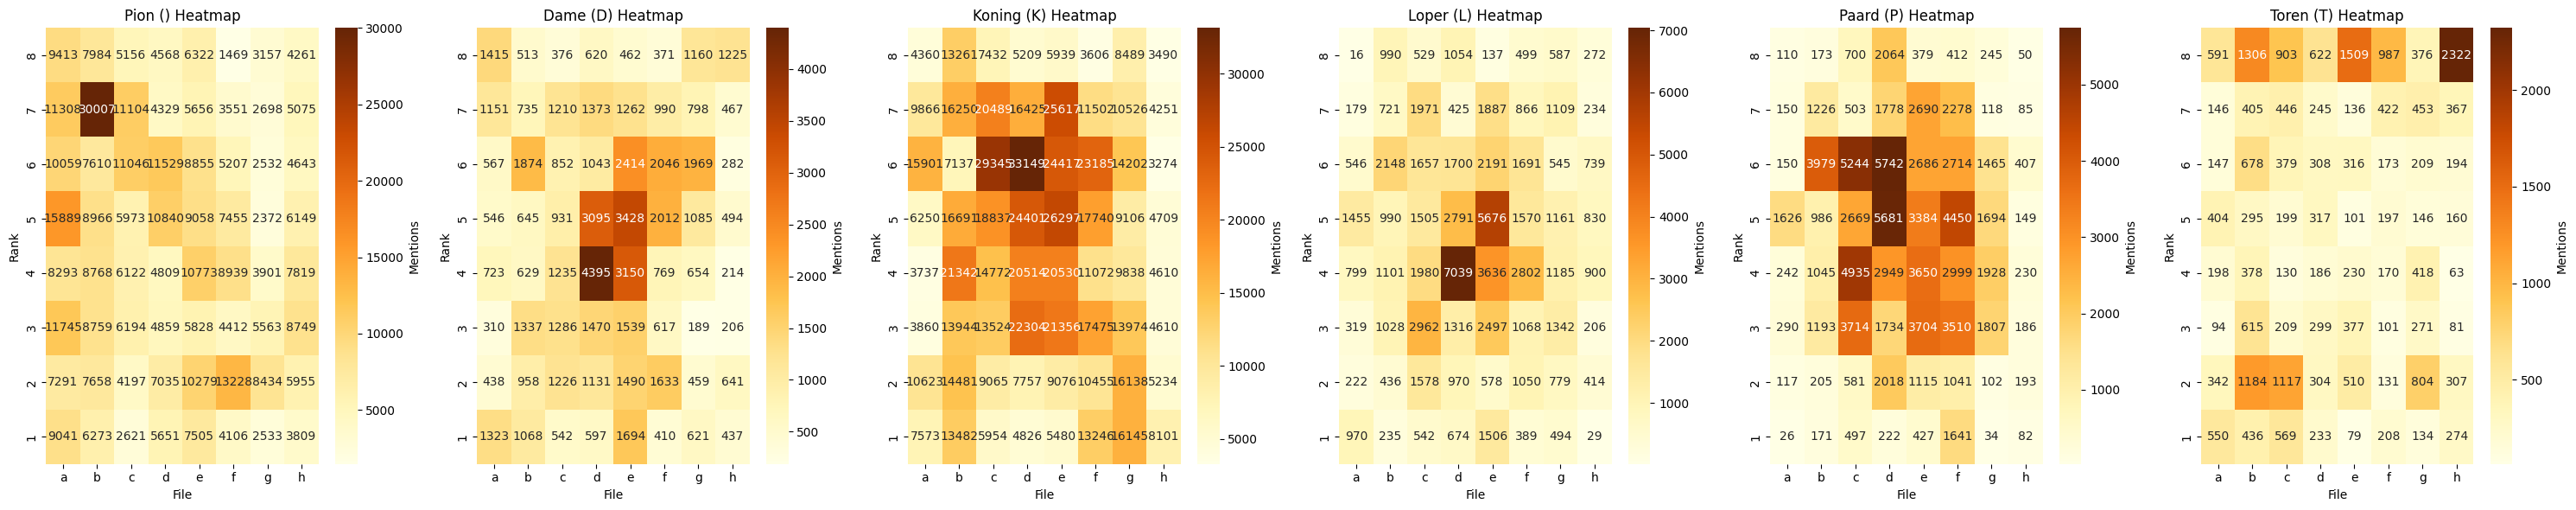

In [27]:
# Plot all heatmaps
n = len(piece_types)
fig, axs = plt.subplots(1, n, figsize=(5 * n, 6), squeeze=False)

piece_name_map = {
    'K': 'Koning', # 'King',
    'D': 'Dame', # 'Queen',
    'T': 'Toren', # 'Rook',
    'L': 'Loper', # 'Bishop',
    'P': 'Paard', # 'Knight',
    '': 'Pion', # 'Pawn'
}

for idx, piece in enumerate(piece_types):
    sns.heatmap(heatmaps[piece], annot=True, fmt='d', cmap='YlOrBr',
                cbar_kws={'label': 'Mentions'}, ax=axs[0][idx])
    axs[0][idx].set_title(f"{piece_name_map[piece]} ({piece}) Heatmap")
    axs[0][idx].set_xlabel("File")
    axs[0][idx].set_ylabel("Rank")

plt.tight_layout()
plt.show()